In [4]:
from einops import rearrange, repeat, reduce
import torch
import cv2
import numpy as np
from matplotlib.pyplot import imshow

In [5]:
images = np.load('../assets/test_images.npy')

# Composition of Axes



### Collapsing batch with height or width to create a new dimension|

batch_height_collapsed shape: (576, 96, 3)


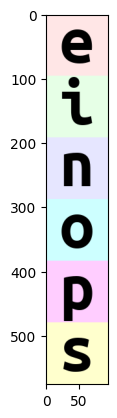

In [6]:
batch_height_collapsed = rearrange(images, 'b h w c -> (b h) w c') * 255.0
print('batch_height_collapsed shape:', batch_height_collapsed.shape)
display_image = batch_height_collapsed.astype(np.uint8)

imshow(display_image)

batch_width_collapsed shape: (96, 576, 3)


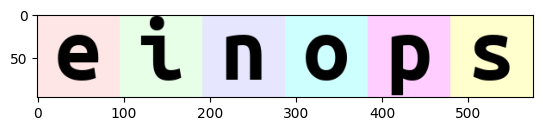

In [7]:
batch_width_collapsed = rearrange(images, 'b h w c -> h (b w) c') * 255.0
print('batch_width_collapsed shape:', batch_width_collapsed.shape)
display_image = batch_width_collapsed.astype(np.uint8)

imshow(display_image)

### Complete Flattening

In [8]:
flattened_batch = rearrange(images, 'b h w c -> (b h w c)') * 255.0
print('flattened_batch shape:', flattened_batch.shape)

flattened_batch shape: (165888,)


# Decomposition of Axes

Decomposing the current batch dimension 6 = (2 3) to 2, 3

decomposed shape: (2, 3, 96, 96, 3)


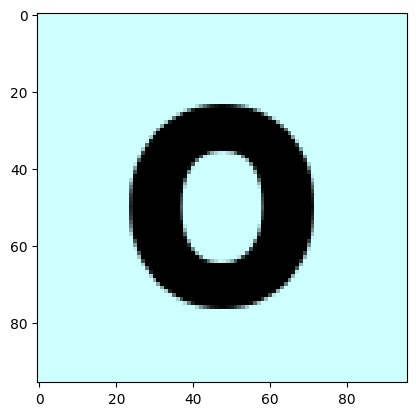

In [9]:
decomposed = rearrange(images, '(b1 b2) h w c -> b1 b2 h w c', b1=2) * 255.0
print('decomposed shape:', decomposed.shape)
imshow(decomposed[1, 0].astype(np.uint8))

Decomposing the first batch dimension and then composing it into height and width.
This creates an image of size (b1 * h, b2 * w, c)

batch_height_width_collapsed shape: (288, 192, 3)


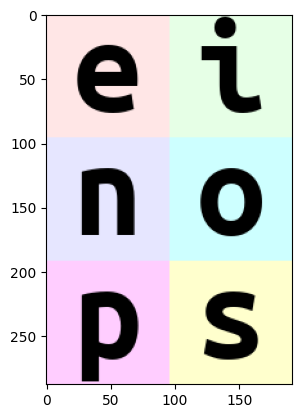

In [10]:
batch_height_width_collapsed = rearrange(images, '(b1 b2) h w c -> (b1 h) (b2 w) c', b1=3) * 255.0
print('batch_height_width_collapsed shape:', batch_height_width_collapsed.shape)
display_image = batch_height_width_collapsed.astype(np.uint8)
imshow(display_image)

# Order of axes

batch_width_collapsed shape: (96, 576, 3)


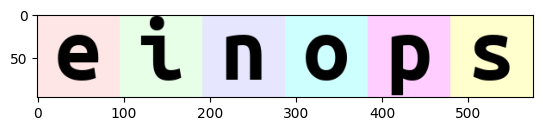

In [11]:
batch_width_collapsed = rearrange(images, "b h w c -> h (b w) c") * 255.0
print('batch_width_collapsed shape:', batch_width_collapsed.shape)
display_image = batch_width_collapsed.astype(np.uint8)
imshow(display_image)


Changing the order of composition has a dramatic impact on the results.
If we use `(w b)` instead of `(b w)`, 6 points (each from an image) will be mixxed together creating a sampling effect.

width_batch_collapsed shape: (96, 576, 3)


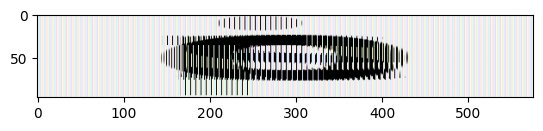

In [12]:
width_batch_collapsed = rearrange(images, 'b h w c -> h (w b) c') * 255.0
print('width_batch_collapsed shape:', width_batch_collapsed.shape)
display_image = width_batch_collapsed.astype(np.uint8)
imshow(display_image)

# Reduce

reduced_image shape: (96, 96, 3)


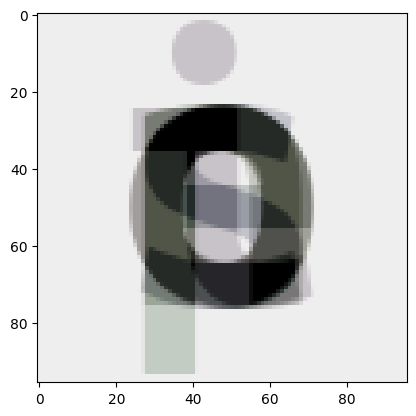

In [15]:
reduced_image = reduce(images, 'b h w c -> h w c', 'mean') * 255.0
print('reduced_image shape:', reduced_image.shape)
display_image = reduced_image.astype(np.uint8)
imshow(display_image)

## Pooling

### Mean pool with windows of 2

b (h h2) (w w2) c (Input Pattern):

* b: The batch dimension remains unchanged.
* (h h2): This is where the magic happens for the height dimension. einops is told to decompose the original h dimension into two parts:
    * h: This represents the new, reduced height.
    * h2: This represents the size of the "window" or "kernel" along the height dimension.
    * The values provided in the arguments (h2=2) tell einops that the original h must be divisible by h2 (e.g., if original h is 96, then h (new) will be 96 / 2 = 48). Each h2 block of pixels will be processed together.
* (w w2): This is the same decomposition process but for the width dimension.
    * w: The new, reduced width.
    * w2: The window/kernel size along the width dimension.
    * Again, w2=2 means the original w must be divisible by 2.
* c: The channel dimension remains unchanged.
* -> b h w c (Output Pattern):

* b: The batch dimension is preserved.
* h: The new, reduced height dimension is present.
* w: The new, reduced width dimension is present.
* c: The channel dimension is preserved.

## Crucially, h2 and w2 are not present in the output pattern. This is the key indicator that these dimensions are being reduced (i.e., collapsed) by the specified operation (mean).

In [27]:
mean_pooled_image = reduce(images, 'b (h h2) (w w2) c -> b h w c', 'mean', h2=2, w2=2) * 255.0
print('mean_pooled_image shape:', mean_pooled_image.shape)

mean_pooled_image shape: (6, 48, 48, 3)


mean_pooled_image shape: (288, 48, 3)


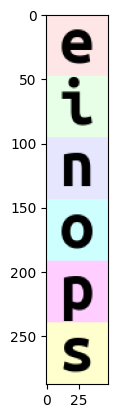

In [29]:
mean_pooled_image = reduce(images, 'b (h h2) (w w2) c -> (b h) w c', 'mean', h2=2, w2=2) * 255.0
print('mean_pooled_image shape:', mean_pooled_image.shape)
display_image = mean_pooled_image.astype(np.uint8)
imshow(display_image)


### Max pool with windows of 2

In [30]:
max_pooled_image = reduce(images, 'b (h h2) (w w2) c -> b h w c', 'max', h2=2, w2=2) * 255.0
print('max_pooled_image shape:', max_pooled_image.shape)

max_pooled_image shape: (6, 48, 48, 3)


max_pooled_image shape: (48, 288, 3)


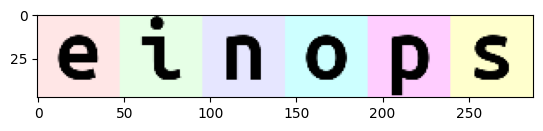

In [31]:
max_pooled_image = reduce(images, 'b (h h2) (w w2) c -> h (b w) c', 'max', h2=2, w2=2) * 255.0
print('max_pooled_image shape:', max_pooled_image.shape)
display_image = max_pooled_image.astype(np.uint8)
imshow(display_image)

### Mean pooling on the channel dimension

mean_pooled_channel_image shape: (192, 288)


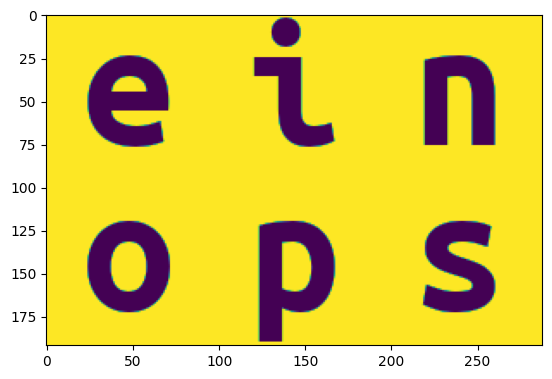

In [35]:
mean_pooled_channel_image = reduce(images, '(b1 b2) h w c -> (b1 h) (b2 w)', 'mean', b1=2) * 255.0
print('mean_pooled_channel_image shape:', mean_pooled_channel_image.shape)
display_image = mean_pooled_channel_image.astype(np.uint8)
imshow(display_image)